# 第30章: モデル選択

## 学習目標
- AICとBICを計算し解釈できる
- 交差検証を実行できる
- Mallows' Cpを理解する
- ステップワイズ選択を適用できる
- 情報量基準の導出を理解する

## 📋 学習メタ情報

### 推定学習時間
**120〜150分**

### 難易度
**★★★★☆** (5段階中4)

---

## 🎯 なぜこの章を学ぶのか？

この章の内容は、実務での統計的データ分析に直結する重要なトピックです。理論と実践の両面から理解を深めましょう。

---

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import seaborn as sns
from sklearn.model_selection import cross_val_score, KFold
from sklearn.linear_model import LinearRegression
from itertools import combinations

plt.rcParams['font.family'] = 'DejaVu Sans'
sns.set_style('whitegrid')
np.random.seed(42)

## 30.1 モデル選択の基本概念

### 目的
複数の候補モデルから最適なモデルを選択

### トレードオフ
- **適合度**: データへの当てはまり（複雑なモデル↑）
- **汎化性能**: 新しいデータへの予測力（単純なモデル↑）

### 過学習
訓練データに過剰に適合し、汎化性能が低下

In [2]:
# サンプルデータの生成
np.random.seed(123)

n = 100
p_true = 3  # True number of relevant predictors
p_total = 10  # Total number of candidate predictors

# Generate predictors
X = np.random.randn(n, p_total)

# True model: only first 3 predictors are relevant
beta_true = np.array([2, -1.5, 1, 0, 0, 0, 0, 0, 0, 0])
y = X @ beta_true + np.random.randn(n) * 0.5

print("モデル選択の基本概念")
print("="*60)
print(f"\nサンプルサイズ: n = {n}")
print(f"候補変数数: p = {p_total}")
print(f"真の係数: {beta_true}")

モデル選択の基本概念

サンプルサイズ: n = 100
候補変数数: p = 10
真の係数: [ 2.  -1.5  1.   0.   0.   0.   0.   0.   0.   0. ]


## 30.2 情報量基準

### AIC (Akaike Information Criterion)
$$\text{AIC} = -2\log L(\hat{\theta}) + 2k$$

- $k$: パラメータ数
- Kullback-Leibler情報量の不偏推定量

### BIC (Bayesian Information Criterion)
$$\text{BIC} = -2\log L(\hat{\theta}) + k \log n$$

- ベイズ事後確率の近似
- AICより大きなペナルティ（n > 7の場合）

In [3]:
# AICとBICの計算
def calculate_aic_bic(X, y, model_indices):
    """Calculate AIC and BIC for a linear regression model."""
    n = len(y)
    k = len(model_indices) + 1  # +1 for intercept
    
    if len(model_indices) == 0:
        # Null model
        y_pred = np.mean(y) * np.ones(n)
    else:
        X_subset = X[:, model_indices]
        model = LinearRegression()
        model.fit(X_subset, y)
        y_pred = model.predict(X_subset)
    
    # RSS and log-likelihood
    rss = np.sum((y - y_pred)**2)
    sigma2 = rss / n
    log_lik = -n/2 * (np.log(2 * np.pi * sigma2) + 1)
    
    # AIC and BIC
    aic = -2 * log_lik + 2 * (k + 1)  # +1 for sigma^2
    bic = -2 * log_lik + (k + 1) * np.log(n)
    
    return aic, bic, rss

print("情報量基準")
print("="*60)

# Compare models with different numbers of predictors
print(f"\n{'変数数':>8} {'AIC':>12} {'BIC':>12} {'RSS':>12}")
print("-"*48)

for p in range(0, p_total + 1):
    indices = list(range(p))
    aic, bic, rss = calculate_aic_bic(X, y, indices)
    print(f"{p:>8} {aic:>12.2f} {bic:>12.2f} {rss:>12.2f}")

情報量基準

     変数数          AIC          BIC          RSS
------------------------------------------------
       0       504.30       509.51       871.58
       1       418.08       425.89       360.71
       2       297.94       308.36       106.34
       3       139.73       152.75        21.43
       4       140.54       156.17        21.17
       5       142.41       160.64        21.14
       6       144.40       165.24        21.14
       7       143.33       166.78        20.50
       8       145.13       171.18        20.46
       9       147.06       175.72        20.45
      10       146.57       177.83        19.95


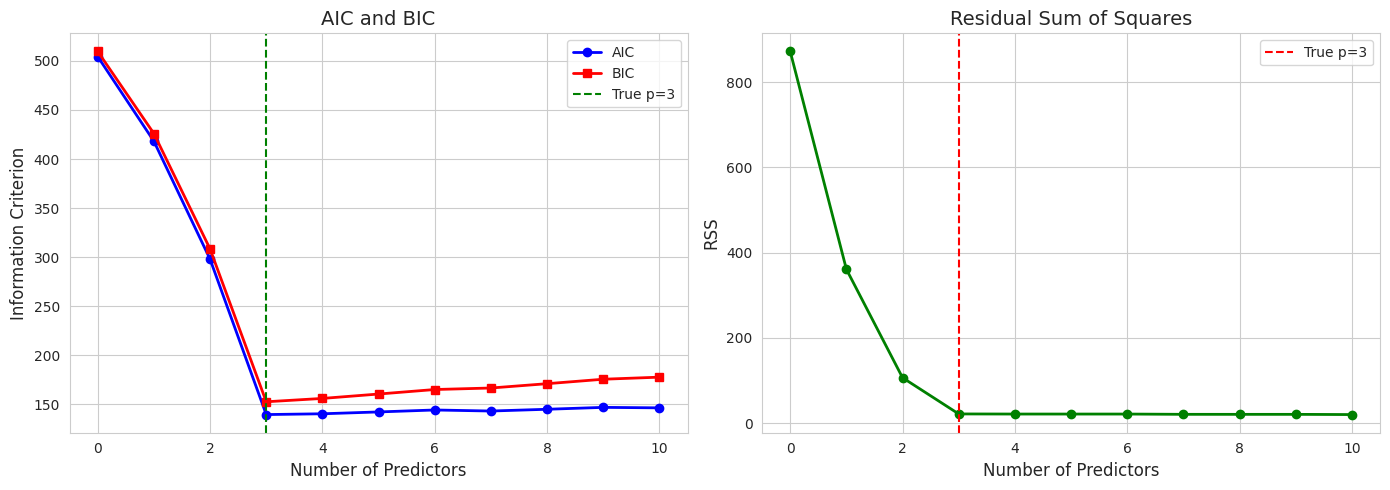


AIC最小: p = 3
BIC最小: p = 3


In [4]:
# Visualize AIC and BIC
aics = []
bics = []
rsses = []

for p in range(0, p_total + 1):
    indices = list(range(p))
    aic, bic, rss = calculate_aic_bic(X, y, indices)
    aics.append(aic)
    bics.append(bic)
    rsses.append(rss)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# AIC and BIC
axes[0].plot(range(p_total + 1), aics, 'b-o', linewidth=2, label='AIC')
axes[0].plot(range(p_total + 1), bics, 'r-s', linewidth=2, label='BIC')
axes[0].axvline(p_true, color='green', linestyle='--', label=f'True p={p_true}')
axes[0].set_xlabel('Number of Predictors', fontsize=12)
axes[0].set_ylabel('Information Criterion', fontsize=12)
axes[0].set_title('AIC and BIC', fontsize=14)
axes[0].legend()

# RSS
axes[1].plot(range(p_total + 1), rsses, 'g-o', linewidth=2)
axes[1].axvline(p_true, color='red', linestyle='--', label=f'True p={p_true}')
axes[1].set_xlabel('Number of Predictors', fontsize=12)
axes[1].set_ylabel('RSS', fontsize=12)
axes[1].set_title('Residual Sum of Squares', fontsize=14)
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"\nAIC最小: p = {np.argmin(aics)}")
print(f"BIC最小: p = {np.argmin(bics)}")

## 30.3 交差検証

### K-fold交差検証
1. データをK個に分割
2. 各foldを順番にテストデータとして使用
3. 予測誤差を平均

### Leave-one-out (LOO)
K = n の交差検証

### 利点
- パラメータ数に依存しない
- 実際の予測性能を評価

In [5]:
# 交差検証
print("交差検証")
print("="*60)

def cv_score_model(X, y, model_indices, cv=5):
    """Calculate cross-validation score for a model."""
    if len(model_indices) == 0:
        # Null model: predict mean
        kf = KFold(n_splits=cv, shuffle=True, random_state=42)
        mse_scores = []
        for train_idx, test_idx in kf.split(X):
            y_pred = np.mean(y[train_idx])
            mse = np.mean((y[test_idx] - y_pred)**2)
            mse_scores.append(mse)
        return np.mean(mse_scores)
    
    X_subset = X[:, model_indices]
    model = LinearRegression()
    scores = cross_val_score(model, X_subset, y, cv=cv, scoring='neg_mean_squared_error')
    return -np.mean(scores)

# Compare models
cv_scores = []
for p in range(0, p_total + 1):
    indices = list(range(p))
    cv_mse = cv_score_model(X, y, indices, cv=5)
    cv_scores.append(cv_mse)

print(f"\n5-fold交差検証MSE:")
print(f"\n{'変数数':>8} {'CV-MSE':>12}")
print("-"*24)
for p, cv_mse in enumerate(cv_scores):
    print(f"{p:>8} {cv_mse:>12.4f}")

print(f"\nCV最小: p = {np.argmin(cv_scores)}")

交差検証

5-fold交差検証MSE:

     変数数       CV-MSE
------------------------
       0       8.8202
       1       3.7062
       2       1.1049
       3       0.2372
       4       0.2452
       5       0.2564
       6       0.2600
       7       0.2566
       8       0.2578
       9       0.2654
      10       0.2557

CV最小: p = 3


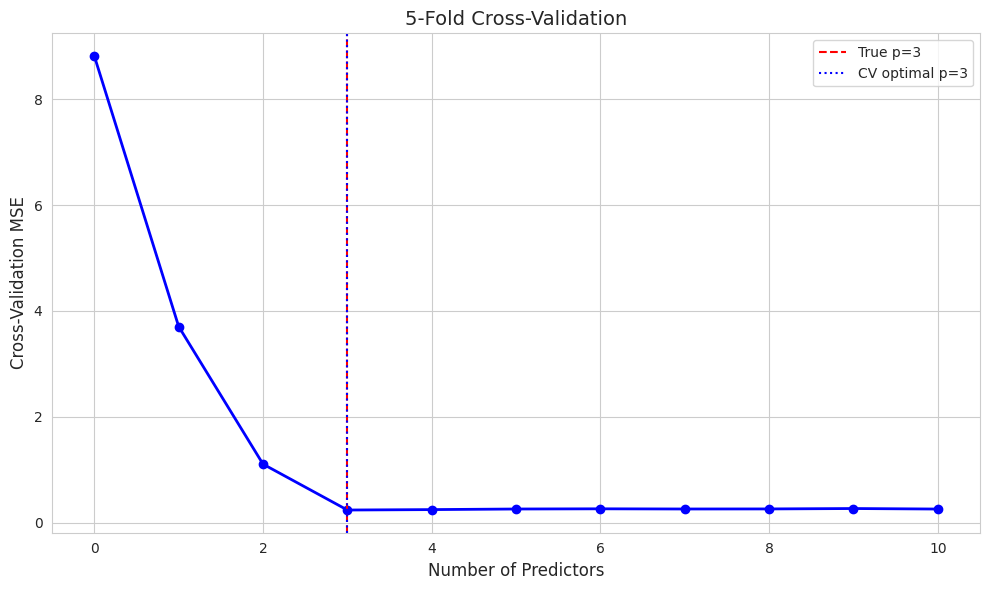

In [6]:
# Visualize CV results
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(range(p_total + 1), cv_scores, 'b-o', linewidth=2)
ax.axvline(p_true, color='red', linestyle='--', label=f'True p={p_true}')
ax.axvline(np.argmin(cv_scores), color='blue', linestyle=':', label=f'CV optimal p={np.argmin(cv_scores)}')
ax.set_xlabel('Number of Predictors', fontsize=12)
ax.set_ylabel('Cross-Validation MSE', fontsize=12)
ax.set_title('5-Fold Cross-Validation', fontsize=14)
ax.legend()

plt.tight_layout()
plt.show()

## 30.4 Mallows' Cp

### 定義
$$C_p = \frac{\text{RSS}_p}{\hat{\sigma}^2} - n + 2p$$

- $\text{RSS}_p$: pパラメータモデルの残差平方和
- $\hat{\sigma}^2$: フルモデルの誤差分散推定値

### 解釈
- 良いモデル: $C_p \approx p$
- $C_p < p$: バイアス、過小定式
- $C_p > p$: 過大定式

Mallows' Cp

     変数数           Cp
------------------------
       0      3791.19
       1      1513.58
       2       380.52
       3         3.60
       4         4.47
       5         6.35
       6         8.34
       7         7.49
       8         9.30
       9        11.24
      10        11.00


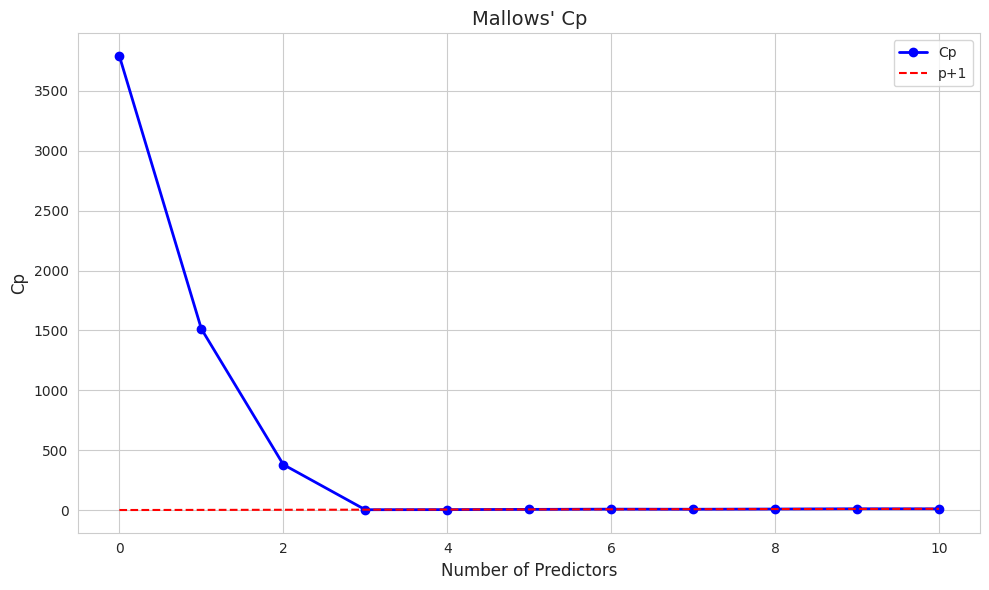

In [7]:
# Mallows' Cp
print("Mallows' Cp")
print("="*60)

# Full model for sigma^2 estimate
model_full = LinearRegression()
model_full.fit(X, y)
y_pred_full = model_full.predict(X)
rss_full = np.sum((y - y_pred_full)**2)
sigma2_hat = rss_full / (n - p_total - 1)

# Calculate Cp for each model
cps = []
for p in range(0, p_total + 1):
    indices = list(range(p))
    _, _, rss_p = calculate_aic_bic(X, y, indices)
    cp = rss_p / sigma2_hat - n + 2 * (p + 1)  # +1 for intercept
    cps.append(cp)

print(f"\n{'変数数':>8} {'Cp':>12}")
print("-"*24)
for p, cp in enumerate(cps):
    print(f"{p:>8} {cp:>12.2f}")

# Plot
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(range(p_total + 1), cps, 'b-o', linewidth=2, label='Cp')
ax.plot(range(p_total + 1), range(1, p_total + 2), 'r--', label='p+1')
ax.set_xlabel('Number of Predictors', fontsize=12)
ax.set_ylabel('Cp', fontsize=12)
ax.set_title("Mallows' Cp", fontsize=14)
ax.legend()

plt.tight_layout()
plt.show()

## 30.5 ステップワイズ選択

### 前進選択 (Forward Selection)
空モデルから開始し、変数を1つずつ追加

### 後退消去 (Backward Elimination)
フルモデルから開始し、変数を1つずつ削除

### 双方向選択 (Both)
追加と削除を繰り返す

In [8]:
# 前進選択法
def forward_selection(X, y, criterion='aic'):
    """Forward selection using AIC or BIC."""
    n, p = X.shape
    selected = []
    remaining = list(range(p))
    
    current_aic, current_bic, _ = calculate_aic_bic(X, y, selected)
    current_score = current_aic if criterion == 'aic' else current_bic
    
    history = [{'step': 0, 'selected': [], 'score': current_score}]
    
    while remaining:
        best_score = np.inf
        best_var = None
        
        for var in remaining:
            candidate = selected + [var]
            aic, bic, _ = calculate_aic_bic(X, y, candidate)
            score = aic if criterion == 'aic' else bic
            
            if score < best_score:
                best_score = score
                best_var = var
        
        if best_score < current_score:
            selected.append(best_var)
            remaining.remove(best_var)
            current_score = best_score
            history.append({'step': len(selected), 'selected': selected.copy(), 'score': current_score})
        else:
            break
    
    return selected, history

# Apply forward selection
selected_aic, history_aic = forward_selection(X, y, 'aic')
selected_bic, history_bic = forward_selection(X, y, 'bic')

print("ステップワイズ選択（前進選択法）")
print("="*60)

print(f"\nAICによる選択: {selected_aic}")
print(f"BICによる選択: {selected_bic}")
print(f"真のモデル: [0, 1, 2]")

ステップワイズ選択（前進選択法）

AICによる選択: [0, 1, 2, 6]
BICによる選択: [0, 1, 2]
真のモデル: [0, 1, 2]


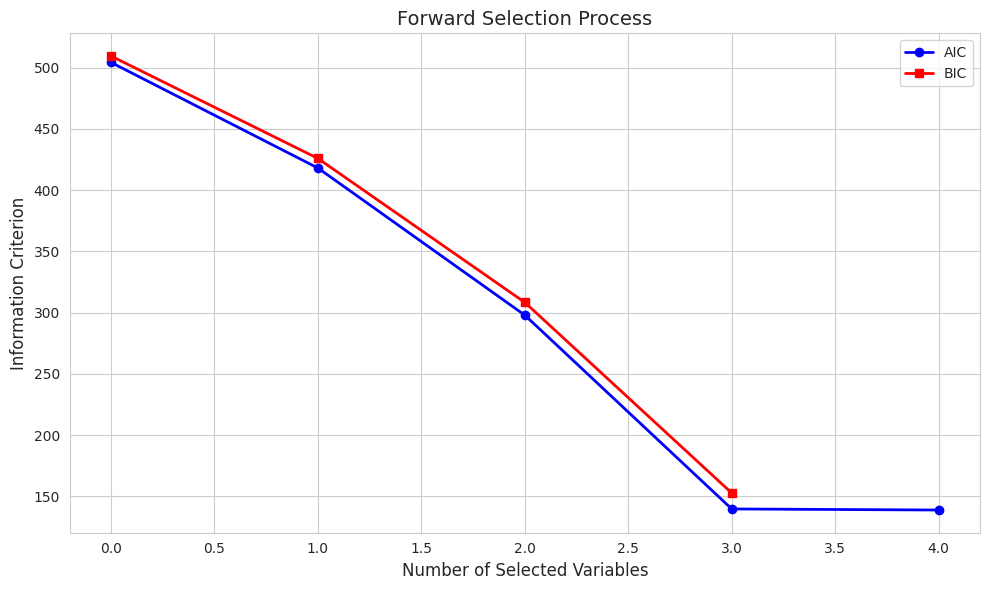

In [9]:
# Visualize selection process
fig, ax = plt.subplots(figsize=(10, 6))

steps_aic = [h['step'] for h in history_aic]
scores_aic = [h['score'] for h in history_aic]
steps_bic = [h['step'] for h in history_bic]
scores_bic = [h['score'] for h in history_bic]

ax.plot(steps_aic, scores_aic, 'b-o', linewidth=2, label='AIC')
ax.plot(steps_bic, scores_bic, 'r-s', linewidth=2, label='BIC')
ax.set_xlabel('Number of Selected Variables', fontsize=12)
ax.set_ylabel('Information Criterion', fontsize=12)
ax.set_title('Forward Selection Process', fontsize=14)
ax.legend()

plt.tight_layout()
plt.show()

## 30.6 情報量基準の導出

### AICの導出
Kullback-Leibler情報量:
$$KL(f, g) = \int f(x) \log\frac{f(x)}{g(x)} dx$$

予測分布と真の分布の乖離度を最小化

### バイアス補正
$$E[\log L(\hat{\theta})] - \log L(\theta_0) \approx k$$

パラメータ数kだけ楽観的になる

In [10]:
# AICバイアスのシミュレーション確認
print("AICバイアスの確認")
print("="*60)

np.random.seed(456)

n_sim = 500
n = 100
p = 5

# True parameters
beta_true_sim = np.random.randn(p)
sigma_true = 1

train_ll = []
test_ll = []

for _ in range(n_sim):
    # Generate training data
    X_train = np.random.randn(n, p)
    y_train = X_train @ beta_true_sim + sigma_true * np.random.randn(n)
    
    # Fit model
    model = LinearRegression()
    model.fit(X_train, y_train)
    y_pred_train = model.predict(X_train)
    
    # Training log-likelihood
    rss_train = np.sum((y_train - y_pred_train)**2)
    sigma2_train = rss_train / n
    ll_train = -n/2 * (np.log(2 * np.pi * sigma2_train) + 1)
    train_ll.append(ll_train)
    
    # Test log-likelihood (using true parameters)
    X_test = np.random.randn(n, p)
    y_test = X_test @ beta_true_sim + sigma_true * np.random.randn(n)
    y_pred_test = model.predict(X_test)
    
    rss_test = np.sum((y_test - y_pred_test)**2)
    sigma2_test = rss_test / n
    ll_test = -n/2 * (np.log(2 * np.pi * sigma2_test) + 1)
    test_ll.append(ll_test)

bias = np.mean(train_ll) - np.mean(test_ll)

print(f"\nパラメータ数: k = {p + 1} (係数+分散)")
print(f"\n訓練対数尤度の平均: {np.mean(train_ll):.2f}")
print(f"テスト対数尤度の平均: {np.mean(test_ll):.2f}")
print(f"\n楽観的バイアス: {bias:.2f}")
print(f"理論値 (k): {p + 1}")

AICバイアスの確認



パラメータ数: k = 6 (係数+分散)

訓練対数尤度の平均: -138.49
テスト対数尤度の平均: -144.51

楽観的バイアス: 6.02
理論値 (k): 6


## 30.7 練習問題

### 問題1
AICとBICの違いと使い分けを説明せよ。

### 問題2
交差検証の折数Kの選び方について説明せよ。

### 問題3
ステップワイズ選択の問題点を3つ挙げよ。

In [11]:
# 問題1の解答
print("問題1: AICとBICの違い")
print("="*60)

print("""
【AIC】
AIC = -2 log L + 2k
・予測性能の最適化
・一致性がない（真のモデルを選ばない場合あり）
・複雑なモデルを選びやすい

【BIC】
BIC = -2 log L + k log n
・モデル選択の一致性がある
・n→∞で真のモデルを選ぶ
・単純なモデルを選びやすい

【ペナルティの比較】
n > 7: BICのペナルティ > AIC
n > e^2 ≈ 7.4: log n > 2

【使い分け】
・予測が目的 → AIC
・真のモデル同定が目的 → BIC
・nが小さい → AIC
・nが大きい → BIC
""")

問題1: AICとBICの違い

【AIC】
AIC = -2 log L + 2k
・予測性能の最適化
・一致性がない（真のモデルを選ばない場合あり）
・複雑なモデルを選びやすい

【BIC】
BIC = -2 log L + k log n
・モデル選択の一致性がある
・n→∞で真のモデルを選ぶ
・単純なモデルを選びやすい

【ペナルティの比較】
n > 7: BICのペナルティ > AIC
n > e^2 ≈ 7.4: log n > 2

【使い分け】
・予測が目的 → AIC
・真のモデル同定が目的 → BIC
・nが小さい → AIC
・nが大きい → BIC



In [12]:
# 問題2の解答
print("問題2: 交差検証の折数K")
print("="*60)

print("""
【Kの選び方】

1. K = 5 または K = 10（標準的）
   - バイアスと分散のバランスが良い
   - 計算コストが妥当

2. K = n (LOO-CV)
   - バイアスが最小
   - 分散が大きい
   - 計算コストが高い

3. K = 2
   - バイアスが大きい
   - 分散が小さい

【トレードオフ】
・Kが大きい → バイアス↓、分散↑
・Kが小さい → バイアス↑、分散↓

【実用的な指針】
・通常: K = 5 または 10
・nが小さい: LOO-CV
・計算コスト重視: K = 5
""")

問題2: 交差検証の折数K

【Kの選び方】

1. K = 5 または K = 10（標準的）
   - バイアスと分散のバランスが良い
   - 計算コストが妥当

2. K = n (LOO-CV)
   - バイアスが最小
   - 分散が大きい
   - 計算コストが高い

3. K = 2
   - バイアスが大きい
   - 分散が小さい

【トレードオフ】
・Kが大きい → バイアス↓、分散↑
・Kが小さい → バイアス↑、分散↓

【実用的な指針】
・通常: K = 5 または 10
・nが小さい: LOO-CV
・計算コスト重視: K = 5



In [13]:
# 問題3の解答
print("問題3: ステップワイズ選択の問題点")
print("="*60)

print("""
【問題点】

1. 局所最適解
   - 全ての組み合わせを探索しない
   - 貪欲法なので最適解を見逃す可能性
   - 変数の追加/削除順序に依存

2. 多重検定の問題
   - 多数の検定を繰り返す
   - p値が正確でない
   - 偽陽性が増加

3. 不安定性
   - データの小さな変化で結果が変わる
   - 再現性が低い
   - ブートストラップで不安定さを確認可能

4. その他
   - 係数のバイアス（選択後の推定）
   - 標準誤差の過小推定
   - R²の過大推定

【代替手法】
・正則化（LASSO, Ridge）
・ベストサブセット選択
・ベイズモデル平均
""")

問題3: ステップワイズ選択の問題点

【問題点】

1. 局所最適解
   - 全ての組み合わせを探索しない
   - 貪欲法なので最適解を見逃す可能性
   - 変数の追加/削除順序に依存

2. 多重検定の問題
   - 多数の検定を繰り返す
   - p値が正確でない
   - 偽陽性が増加

3. 不安定性
   - データの小さな変化で結果が変わる
   - 再現性が低い
   - ブートストラップで不安定さを確認可能

4. その他
   - 係数のバイアス（選択後の推定）
   - 標準誤差の過小推定
   - R²の過大推定

【代替手法】
・正則化（LASSO, Ridge）
・ベストサブセット選択
・ベイズモデル平均



## ⚠️ よくある間違いと解決策

統計分析では、手法の前提条件を確認せずに適用してしまうことがよくあります。必ず前提を確認し、適切な手法を選択しましょう。

---

## 📝 理解度チェック

この章で学んだ内容を振り返り、重要な概念を自分の言葉で説明できるか確認しましょう。

---

## 📚 まとめ

お疲れ様でした！この章で学んだ手法は、実際のデータ分析で頻繁に使われます。実データで試して理解を深めましょう。

---